In [1]:
# GLiNER Column-Driven Pollution Detection - Full Dataset Processing (v3.0)
# 
# This notebook applies the column-driven GLiNER detector to the SOBR laptop dataset:
# 1. Load all posts from SOBR laptop dataset
# 2. Run GLiNER with per-row column selection (only prompts for non-null demographic columns)
# 3. Apply masking and write results to sobr_laptop.arrow (post_masked column)
# 4. Write pollution logs to pollution_logs_laptop.arrow
# 5. Comprehensive visualizations: column-based distributions, per-column recall, coverage analysis
#
# v2.0 Detector Optimizations (GLiNERDetector):
# - Batched inference via GLiNER.inference() API (throughput speedup)
# - Length-based bucketing to minimize padding waste
# - Bi-encoder prompt embedding caching (when available)
# - VRAM-aware bucket count auto-computation
#
# v3.0 Execution Optimizations (configured via conf/*/pipeline.yaml):
# - CUDA Graph capture (optional)
# - torch.compile (optional)
# - Sequence packing (optional)
# - Async prefetching (optional)
# - GPU span filtering (optional)

In [2]:
# Import dependencies
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow as pa
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
from tqdm.auto import tqdm

# Ensure notebook uses latest local code (helpful after pulling changes)
import importlib
import neuro_stylometry.config as _ns_config
import neuro_stylometry.phase_a_pipeline as _ns_phase_a
import neuro_stylometry.pollution_guard.semantic_chunker as _ns_chunker
import neuro_stylometry.pollution_guard.gliner_detector as _ns_gd
importlib.reload(_ns_config)
importlib.reload(_ns_chunker)
importlib.reload(_ns_gd)
importlib.reload(_ns_phase_a)

from neuro_stylometry.phase_a_pipeline import PhaseAPipeline
from neuro_stylometry.factories.strategy_factory import StrategyFactory
from neuro_stylometry.pollution_guard.explicit_recall import compute_explicit_recall
from neuro_stylometry.data_engine.dataset import SOBRDataset
from neuro_stylometry.data_engine.schemas import get_demographic_columns, POLLUTION_LOG_SCHEMA

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

# Initialize pipeline with strict YAML config authority
strategy = StrategyFactory.create_filter_strategy()
pipeline = PhaseAPipeline.from_yaml(strategy=strategy, mode="laptop")

# Access components via facade methods
detector = pipeline.get_detector()
masker = pipeline.get_masker()

print("=" * 80)
print("COLUMN-DRIVEN GLINER CONFIGURATION (Batch Inference + Execution Optimizations)")
print("=" * 80)
print(f"GLiNER model: {detector.model.__class__.__name__}")
print(f"GLiNER device: {detector.device}")
print(f"GLiNER max_length: {detector.max_length}")
print(f"Chunking mode: {detector.chunker.config.mode}")
print(f"Legacy sequential mode: {detector.budget_config.legacy_sequential_mode}")
print(f"Confidence threshold: {detector.confidence_threshold}")
print(f"Configured SOBR columns: {detector.taxonomy.get_all_columns()}")
print(f"Total unique mask tokens: {len(set(detector.taxonomy.get_mask_tokens().values()))}")
print("-" * 40)
print("BATCH INFERENCE OPTIMIZATION SETTINGS:")
print(f"  Batching enabled: {detector.batch_config.enable_batching}")
print(f"  Batch size: {detector.batch_config.batch_size}")
print(f"  Num buckets (length bucketing): {detector.batch_config.num_buckets}")
print(f"  Min bucket size: {detector.batch_config.min_bucket_size}")
print(f"  Prompt caching enabled: {detector.batch_config.enable_prompt_caching}")
print(f"  Is bi-encoder (supports prompt caching): {detector.is_bi_encoder}")
print("-" * 40)
print("ADVANCED EXECUTION OPTIMIZATION SETTINGS (from YAML):")
execution_cfg = pipeline.config.get("execution", {})
print(f"  CUDA graphs enabled: {execution_cfg.get('enable_cuda_graphs', False)}")
print(f"  torch.compile enabled: {execution_cfg.get('enable_torch_compile', False)}")
if execution_cfg.get("enable_torch_compile", False):
    print(f"    mode: {execution_cfg.get('torch_compile_mode')}")
    print(f"    backend: {execution_cfg.get('torch_compile_backend')}")
seq_pack = execution_cfg.get("sequence_packing", {})
print(f"  Sequence packing enabled: {seq_pack.get('enabled', False)}")
prefetch = execution_cfg.get("async_prefetch", {})
print(f"  Async prefetch enabled: {prefetch.get('enabled', False)}")
span_filter = execution_cfg.get("gpu_span_filter", {})
print(f"  GPU span filter enabled: {span_filter.get('enabled', False)}")
print("=" * 80)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib\site-packages\transformers\convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: http

COLUMN-DRIVEN GLINER CONFIGURATION (Batch Inference + Execution Optimizations)
GLiNER model: UniEncoderSpanGLiNER
GLiNER device: cuda
GLiNER max_length: 512
Chunking mode: single_sentence
Legacy sequential mode: False
Confidence threshold: 0.85
Configured SOBR columns: ['birth_year', 'female', 'nationality', 'political_leaning', 'extrovert', 'sensing', 'feeling', 'judging']
Total unique mask tokens: 5
----------------------------------------
BATCH INFERENCE OPTIMIZATION SETTINGS:
  Batching enabled: True
  Batch size: 32
  Num buckets (length bucketing): 5
  Min bucket size: 4
  Prompt caching enabled: True
  Is bi-encoder (supports prompt caching): False
----------------------------------------
ADVANCED EXECUTION OPTIMIZATION SETTINGS (from YAML):
  CUDA graphs enabled: False
  torch.compile enabled: False
  Sequence packing enabled: False
  Async prefetch enabled: True
  GPU span filter enabled: True


## 1. Load SOBR Sample Data

In [7]:
# Load FULL SOBR laptop dataset
dataset_path = Path("../artifacts/data/sobr_laptop.arrow")
dataset = SOBRDataset(arrow_path=dataset_path, seed=42)

print(f"Loaded {len(dataset.table)} posts from SOBR laptop dataset")
print(f"Demographic columns: {get_demographic_columns()}")
print(f"\nDataset schema columns: {dataset.table.schema.names}")

Loaded 10020 posts from SOBR laptop dataset
Demographic columns: ['birth_year', 'female', 'nationality', 'political_leaning', 'extrovert', 'sensing', 'feeling', 'judging']

Dataset schema columns: ['post_id', 'author_id', 'post', 'post_masked', 'birth_year', 'female', 'nationality', 'political_leaning', 'extrovert', 'sensing', 'feeling', 'judging', 'split', 'text_length']


## 2. Initialize GLiNER Detector

Initialize GLiNER with SOBR-specific taxonomy.

In [5]:
# Display taxonomy details
taxonomy = detector.taxonomy

print("=" * 80)
print("COLUMN-DRIVEN TAXONOMY DETAILS")
print("=" * 80)
print(f"Configured columns: {len(taxonomy.get_all_columns())}")
for col in taxonomy.get_all_columns():
    col_cfg = taxonomy.column_prompts[col]
    print(f"\n{col}:")
    print(f"  Prompts: {col_cfg.prompts[:2]}...")
    print(f"  Distractors: {col_cfg.distractors[:1]}...")
    print(f"  Mask token: {col_cfg.mask_token}")
    print(f"  Max width: {col_cfg.width}")
    print(f"  Reference patterns: {len(col_cfg.reference_patterns)}")
print("=" * 80)

COLUMN-DRIVEN TAXONOMY DETAILS
Configured columns: 8

birth_year:
  Prompts: ['age statement', 'self-identified age']...
  Distractors: ['third-person age mention']...
  Mask token: [MASK:AGE]
  Max width: 6
  Reference patterns: 7

female:
  Prompts: ['gender self-identification', 'self-identified gender']...
  Distractors: ['third-person gender mention']...
  Mask token: [MASK:GENDER]
  Max width: 4
  Reference patterns: 6

nationality:
  Prompts: ['nationality statement', 'self-identified nationality']...
  Distractors: ['third-person nationality mention']...
  Mask token: [MASK:NATIONALITY]
  Max width: 8
  Reference patterns: 3

political_leaning:
  Prompts: ['political affiliation', 'self-identified political leaning']...
  Distractors: ['third-person political mention']...
  Mask token: [MASK:POLITICAL]
  Max width: 6
  Reference patterns: 4

extrovert:
  Prompts: ['MBTI type', 'personality type identifier']...
  Distractors: ['third-person personality mention']...
  Mask token:

## 3. Run Pollution Detection

Detect pollution spans in sample posts.

In [8]:
# Compute per-row active columns (only columns with non-null values)
print("Computing per-row active columns...")
demographic_cols = get_demographic_columns()
table = dataset.table

active_columns_per_row = []
for i in tqdm(range(len(table)), desc="Analyzing rows"):
    row_columns = []
    for col in demographic_cols:
        val = table[col][i].as_py()
        if val is not None:
            row_columns.append(col)
    active_columns_per_row.append(row_columns if row_columns else None)

# Statistics
rows_with_any_demo = sum(1 for cols in active_columns_per_row if cols)
print(f"\nRows with at least one demographic attribute: {rows_with_any_demo}/{len(table)} ({100*rows_with_any_demo/len(table):.1f}%)")

# Column frequency
col_freq = Counter()
for row_cols in active_columns_per_row:
    if row_cols:
        col_freq.update(row_cols)

print("\nDemographic column frequency:")
for col, count in col_freq.most_common():
    print(f"  {col:20s}: {count:6d} ({100*count/len(table):5.1f}%)")

Computing per-row active columns...


Analyzing rows:   0%|          | 0/10020 [00:00<?, ?it/s]


Rows with at least one demographic attribute: 10020/10020 (100.0%)

Demographic column frequency:
  nationality         :   3071 ( 30.6%)
  political_leaning   :   1765 ( 17.6%)
  feeling             :   1666 ( 16.6%)
  sensing             :   1540 ( 15.4%)
  birth_year          :   1507 ( 15.0%)
  female              :   1365 ( 13.6%)
  extrovert           :   1320 ( 13.2%)
  judging             :   1319 ( 13.2%)


In [9]:
# Run GLiNER pollution detection with per-row column selection
print("\n" + "=" * 80)
print("RUNNING GLINER DETECTION ON FULL DATASET")
print("=" * 80)

posts = table["post"].to_pylist()
post_ids = table["post_id"].to_pylist()

# Pretty-print relevant config before running detection
print("Full GLiNER configuration:")
for key, value in pipeline.config["gliner"].items():
    print(f"  {key}: {value}")

print("\nExecution (advanced optimizations) configuration:")
for key, value in pipeline.config.get("execution", {}).items():
    print(f"  {key}: {value}")

print("\nPaths configuration:")
for key, value in pipeline.config["paths"].items():
    print(f"  {key}: {value}")


RUNNING GLINER DETECTION ON FULL DATASET
Full GLiNER configuration:
  model: urchade/gliner_large-v2.1
  confidence_threshold: 0.85
  batch_size: 32
  device: auto
  taxonomy_path: conf/base/gliner_taxonomy.yaml
  compute_explicit_recall: True
  explicit_recall_threshold: 0.95
  batch_inference: {'enable_batching': True, 'num_buckets': None, 'min_bucket_size': 4, 'enable_prompt_caching': True}
  chunking: {'mode': 'single_sentence', 'legacy_sequential_mode': False, 'parallel_chunking_workers': 0, 'parallel_chunking_min_texts': 512}

Execution (advanced optimizations) configuration:
  enable_cuda_graphs: False
  cuda_graph_warmup: 3
  cuda_graph_cache_size: 8
  enable_torch_compile: False
  torch_compile_mode: reduce-overhead
  torch_compile_fullgraph: False
  torch_compile_dynamic: True
  torch_compile_backend: inductor
  sequence_packing: {'enabled': False, 'max_packed_length': 1024, 'min_sequences_to_pack': 3, 'use_block_diagonal_mask': True, 'pack_by_similarity': True}
  async_pref

In [ ]:
# Detect spans with per-row column selection using OPTIMIZED BATCH INFERENCE
import time

# Use detector's configured batch size (YAML authority)
batch_size = int(detector.batch_config.batch_size)

print("=" * 80)
print("RUNNING GLINER BATCH INFERENCE")
print("=" * 80)
print(f"Batch size: {batch_size}")
print(f"Batching enabled: {detector.batch_config.enable_batching}")
print(f"Num buckets: {detector.batch_config.num_buckets}")
print("Progress bars:")
print("  1) GLiNER chunking = texts processed")
print("  2) GLiNER inference = inference batches across bucketed chunks (not posts)")

# Advanced execution settings (configured via YAML)
execution_cfg = pipeline.config.get("execution", {})
print("-" * 40)
print("Execution optimizations (configured):")
print(f"  CUDA graphs: {execution_cfg.get('enable_cuda_graphs', False)}")
print(f"  torch.compile: {execution_cfg.get('enable_torch_compile', False)}")
print(f"  sequence_packing.enabled: {execution_cfg.get('sequence_packing', {}).get('enabled', False)}")
print(f"  async_prefetch.enabled: {execution_cfg.get('async_prefetch', {}).get('enabled', False)}")
print(f"  gpu_span_filter.enabled: {execution_cfg.get('gpu_span_filter', {}).get('enabled', False)}")

# Time the detection
start_time = time.perf_counter()

entities_batch = detector.detect_spans(
    posts,
    active_columns=active_columns_per_row,
    batch_size=batch_size,
    show_progress=True,
 )

elapsed = time.perf_counter() - start_time

# Count detections
total_detections = sum(len(entities) for entities in entities_batch)
posts_with_detections = sum(1 for entities in entities_batch if entities)

print("=" * 80)
print("DETECTION RESULTS")
print("=" * 80)
print(f"Total detections: {total_detections:,}")
print(f"Posts with detections: {posts_with_detections:,}/{len(posts):,} ({100*posts_with_detections/len(posts):.1f}%)")
print(f"Elapsed time: {elapsed:.2f} seconds")
print(f"Throughput: {len(posts)/elapsed:.1f} posts/sec")

# Show prompt cache stats (bi-encoder optimization)
cache_stats = detector.get_cache_stats()
print("-" * 40)
print("PROMPT CACHE STATS:")
print(f"  Cached label sets: {cache_stats['prompt_cache_entries']}")
print(f"  Bi-encoder model: {cache_stats['is_bi_encoder']}")
print(f"  Caching enabled: {cache_stats['prompt_caching_enabled']}")

# Show example detections
print("-" * 40)
print("Example detections (first 3 posts with entities):")
shown = 0
for i, entities in enumerate(entities_batch):
    if entities and shown < 3:
        print(f"\nPost {i} (columns: {active_columns_per_row[i]}):")
        for entity in entities[:3]:
            print(f"  - {entity['label']:20s}: '{entity['text']}' (conf={entity['score']:.2f})")
        shown += 1
print("=" * 80)

RUNNING GLINER BATCH INFERENCE
Batch size: 32
Batching enabled: True
Num buckets: 5
Progress bars:
  1) GLiNER chunking = texts processed
  2) GLiNER inference = inference batches across bucketed chunks (not posts)
----------------------------------------
Execution optimizations (configured):
  CUDA graphs: False
  torch.compile: False
  sequence_packing.enabled: False
  async_prefetch.enabled: True
  gpu_span_filter.enabled: True


GLiNER chunking:   0%|          | 0/10020 [00:00<?, ?text/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (688 > 512). Running this sequence through the model will result in indexing errors


## Apply Masking and Write Outputs

Apply typed masks to detected spans and write:
1. Updated sobr_laptop.arrow with post_masked column populated
2. pollution_logs_laptop.arrow with detection metadata

In [ ]:
# Apply masking and collect pollution logs
print("=" * 80)
print("APPLYING MASKING")
print("=" * 80)

post_masked_list = []
pollution_log_records = []

for i, (post, entities) in enumerate(tqdm(zip(posts, entities_batch), total=len(posts), desc="Masking")):
    if entities:
        # Apply masking
        result = masker.mask_spans(post, entities, post_ids[i])
        post_masked_list.append(result.masked_text)
        
        # Collect pollution logs
        for log_entry in result.mask_log:
            pollution_log_records.append({
                "post_id": log_entry["post_id"],
                "span_start": log_entry["span_start"],
                "span_end": log_entry["span_end"],
                "span_text": log_entry["span_text"],
                "entity_type": log_entry["entity_type"],
                "confidence": log_entry["confidence"],
                "mask_token": log_entry["mask_token"],
            })
    else:
        # No entities -> no masking
        post_masked_list.append(post)

print(f"\nMasked {len([p for p in post_masked_list if '[MASK:' in p]):,} posts")
print(f"Pollution log records: {len(pollution_log_records):,}")

In [ ]:
# Write updated sobr_laptop.arrow with post_masked column
print("\n" + "=" * 80)
print("WRITING OUTPUTS")
print("=" * 80)

# Add post_masked column to table
post_masked_array = pa.array(post_masked_list, type=pa.string())
table_with_masked = table.set_column(
    table.schema.get_field_index("post_masked"),
    "post_masked",
    post_masked_array
)

output_dataset_path = Path("../artifacts/data/sobr_laptop.arrow")
pa.ipc.RecordBatchFileWriter(output_dataset_path, table_with_masked.schema).write_table(table_with_masked)

print(f"✓ Written updated dataset to {output_dataset_path}")
print(f"  Rows: {len(table_with_masked):,}")
print(f"  post_masked column populated: {(table_with_masked['post_masked'] != table_with_masked['post']).sum()} rows")

# Write pollution logs
if pollution_log_records:
    pollution_logs_table = pa.Table.from_pylist(pollution_log_records, schema=POLLUTION_LOG_SCHEMA)
    pollution_logs_path = Path("../artifacts/data/pollution_logs_laptop.arrow")
    pa.ipc.RecordBatchFileWriter(pollution_logs_path, pollution_logs_table.schema).write_table(pollution_logs_table)
    
    print(f"\n✓ Written pollution logs to {pollution_logs_path}")
    print(f"  Records: {len(pollution_logs_table):,}")
else:
    print("\n⚠ No pollution logs to write")

print("=" * 80)

## 4. Visualize Label Distribution

Plot the distribution of detected entity types.

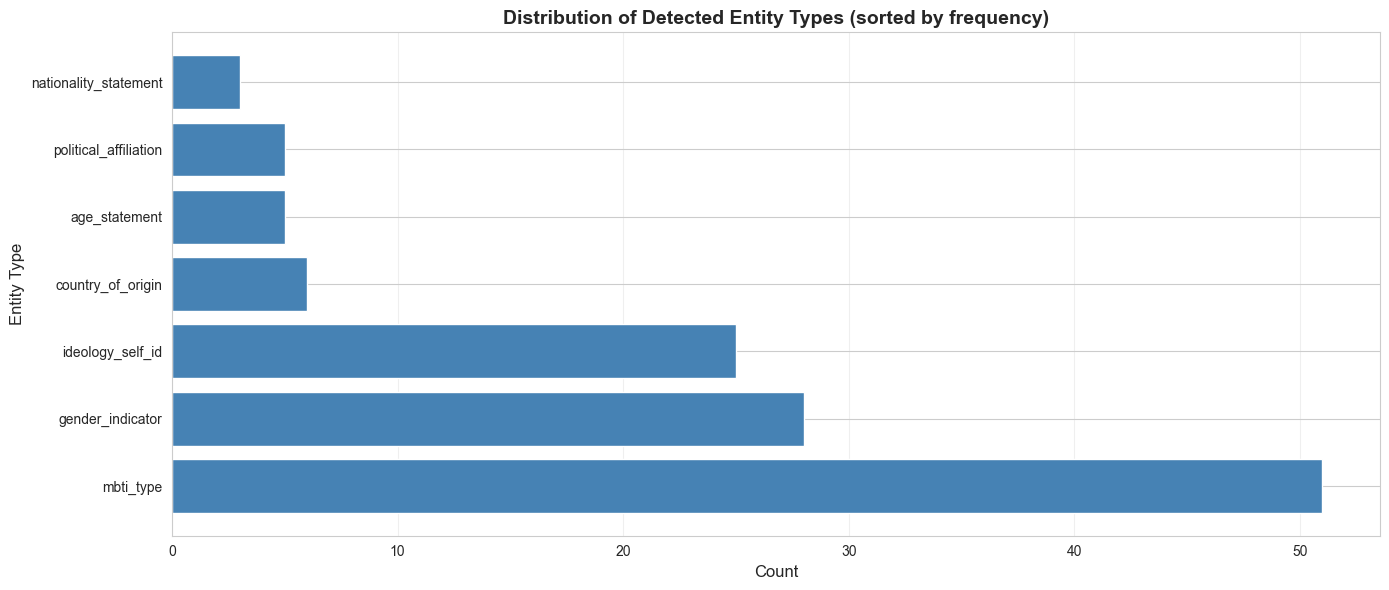

ENTITY DETECTION STATISTICS

Total unique entity types detected: 7
Total entity spans detected: 123

Top 10 most common entity types:
  mbti_type                     :   51 ( 41.5%)
  gender_indicator              :   28 ( 22.8%)
  ideology_self_id              :   25 ( 20.3%)
  country_of_origin             :    6 (  4.9%)
  age_statement                 :    5 (  4.1%)
  political_affiliation         :    5 (  4.1%)
  nationality_statement         :    3 (  2.4%)


C:\Users\20232788\AppData\Local\Temp\ipykernel_25828\921400369.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(


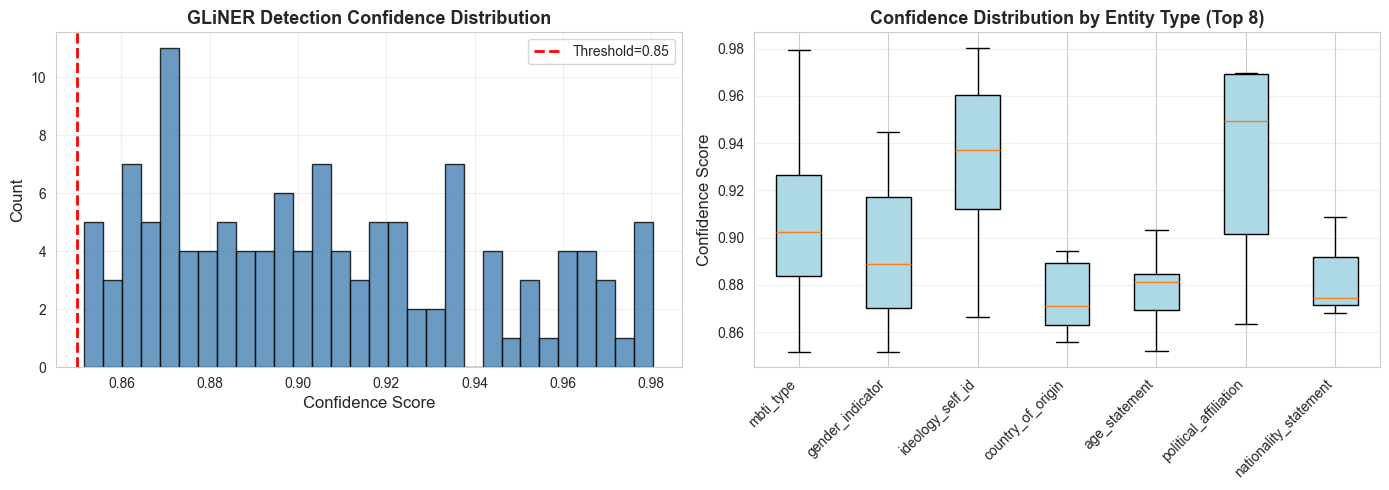


SPAN CHARACTER-LENGTH STATISTICS
count    123.000000
mean       6.113821
std        4.065455
min        2.000000
25%        4.000000
50%        5.000000
75%        7.000000
90%       10.800000
95%       16.000000
99%       19.000000
max       24.000000


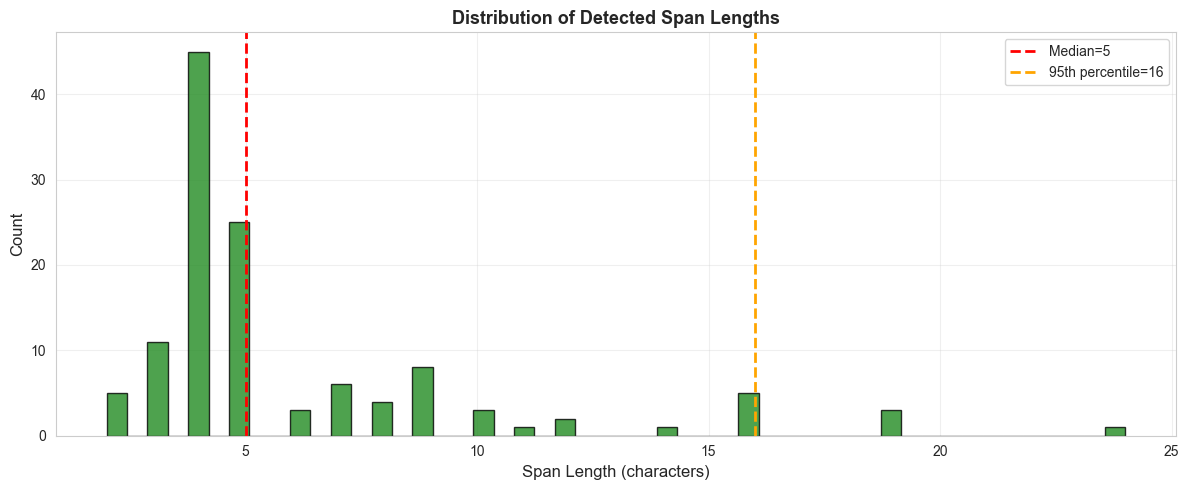

In [ ]:
# Load pollution logs for analysis
pollution_logs = pa.ipc.RecordBatchFileReader(Path("../artifacts/data/pollution_logs_laptop.arrow")).read_all()

# Column-based entity distribution
print("=" * 80)
print("COLUMN-BASED DETECTION STATISTICS")
print("=" * 80)

column_counts = Counter(pollution_logs["entity_type"].to_pylist())
print(f"\nTotal detections by SOBR column:")
for col, count in column_counts.most_common():
    pct = 100 * count / len(pollution_logs)
    print(f"  {col:20s}: {count:6,d} ({pct:5.1f}%)")

# Plot column distribution
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Detection count by column
cols_sorted = sorted(column_counts.items(), key=lambda x: x[1], reverse=True)
cols = [c[0] for c in cols_sorted]
counts = [c[1] for c in cols_sorted]

axes[0].barh(cols, counts, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Detection Count', fontsize=12)
axes[0].set_ylabel('SOBR Column', fontsize=12)
axes[0].set_title('Pollution Detections by SOBR Demographic Column', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: Confidence distribution by column (top 6)
top_cols = [c[0] for c in cols_sorted[:6]]
scores_by_col = {col: [] for col in top_cols}
for i in range(len(pollution_logs)):
    col = pollution_logs["entity_type"][i].as_py()
    if col in scores_by_col:
        scores_by_col[col].append(pollution_logs["confidence"][i].as_py())

bp = axes[1].boxplot(
    [scores_by_col[col] for col in top_cols],
    labels=top_cols,
    patch_artist=True,
    showfliers=False,
)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[1].set_ylabel('GLiNER Confidence', fontsize=12)
axes[1].set_title('Confidence Distribution by Column (Top 6)', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].axhline(detector.confidence_threshold, color='red', linestyle='--', linewidth=2, 
                label=f'Threshold={detector.confidence_threshold:.2f}')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("=" * 80)

## 5. Calculate Explicit Recall

Compare GLiNER detections against simple regex baseline to measure recall on explicit patterns.

EXPLICIT RECALL (GLiNER vs Regex Reference)

Overall Recall: 2.7%

Per-Label Recall:
  age_statement                 : 12.5%
  mbti_type                     : 9.1%
  nationality_statement         : 0.2%
  country_of_origin             : 0.0%
  gender_indicator              : 0.0%


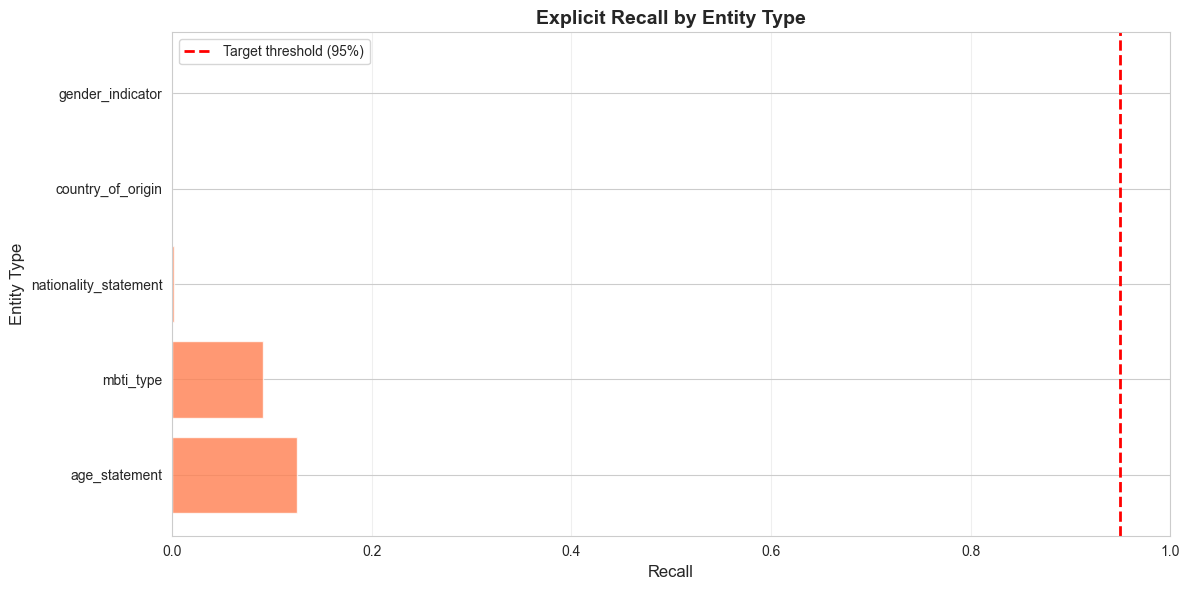


DETECTION COUNTS
  Total reference spans:    866
  Matched reference spans:  23
  Total GLiNER detections:  123

Target explicit recall threshold: 95.0%
✗ Target not met: 2.7% < 95.0%


In [ ]:
# Per-column explicit recall
print("=" * 80)
print("PER-COLUMN EXPLICIT RECALL")
print("=" * 80)

# Get per-column reference patterns
reference_patterns_by_col = taxonomy.get_reference_patterns()

# Compute explicit recall
recall_result = compute_explicit_recall(posts, entities_batch, reference_patterns_by_col)

overall = recall_result.get("overall")
print(f"\nOverall Recall: {overall:.1%}" if overall is not None else "\nOverall Recall: N/A")

per_label = recall_result.get("per_label", {})
if per_label:
    print("\nPer-Column Recall:")
    recall_data = []
    for col in demographic_cols:
        r = per_label.get(col)
        if r is not None:
            recall_data.append({'column': col, 'recall': r})
            print(f"  {col:20s}: {r:.1%}")
    
    # Plot per-column recall
    if recall_data:
        recall_df = pd.DataFrame(recall_data)
        
        fig, ax = plt.subplots(figsize=(12, 6))
        colors = ['forestgreen' if r >= 0.9 else 'orange' if r >= 0.7 else 'coral' 
                  for r in recall_df['recall']]
        ax.barh(recall_df['column'], recall_df['recall'], color=colors, alpha=0.8)
        ax.axvline(0.95, color='red', linestyle='--', linewidth=2, label="Target (95%)")
        ax.set_xlabel('Explicit Recall', fontsize=12)
        ax.set_ylabel('SOBR Column', fontsize=12)
        ax.set_title('Explicit Recall by Demographic Column (Regex Baseline)', fontsize=14, fontweight='bold')
        ax.set_xlim(0, 1.05)
        ax.legend()
        ax.grid(alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()

print(f"\nTotal reference spans:    {recall_result.get('total_reference_spans', 0):,}")
print(f"Matched reference spans:  {recall_result.get('matched_reference_spans', 0):,}")
print(f"Total GLiNER detections:  {total_detections:,}")

# Check threshold
threshold = float(pipeline.config["gliner"]["explicit_recall_threshold"])
print(f"\nTarget threshold: {threshold:.1%}")
if overall is not None:
    status = "✓ PASS" if overall >= threshold else "✗ FAIL"
    print(f"{status}: {overall:.1%} {'≥' if overall >= threshold else '<'} {threshold:.1%}")
print("=" * 80)

## 6. Entity Co-occurrence Analysis

Analyze which entity types tend to co-occur in the same posts.

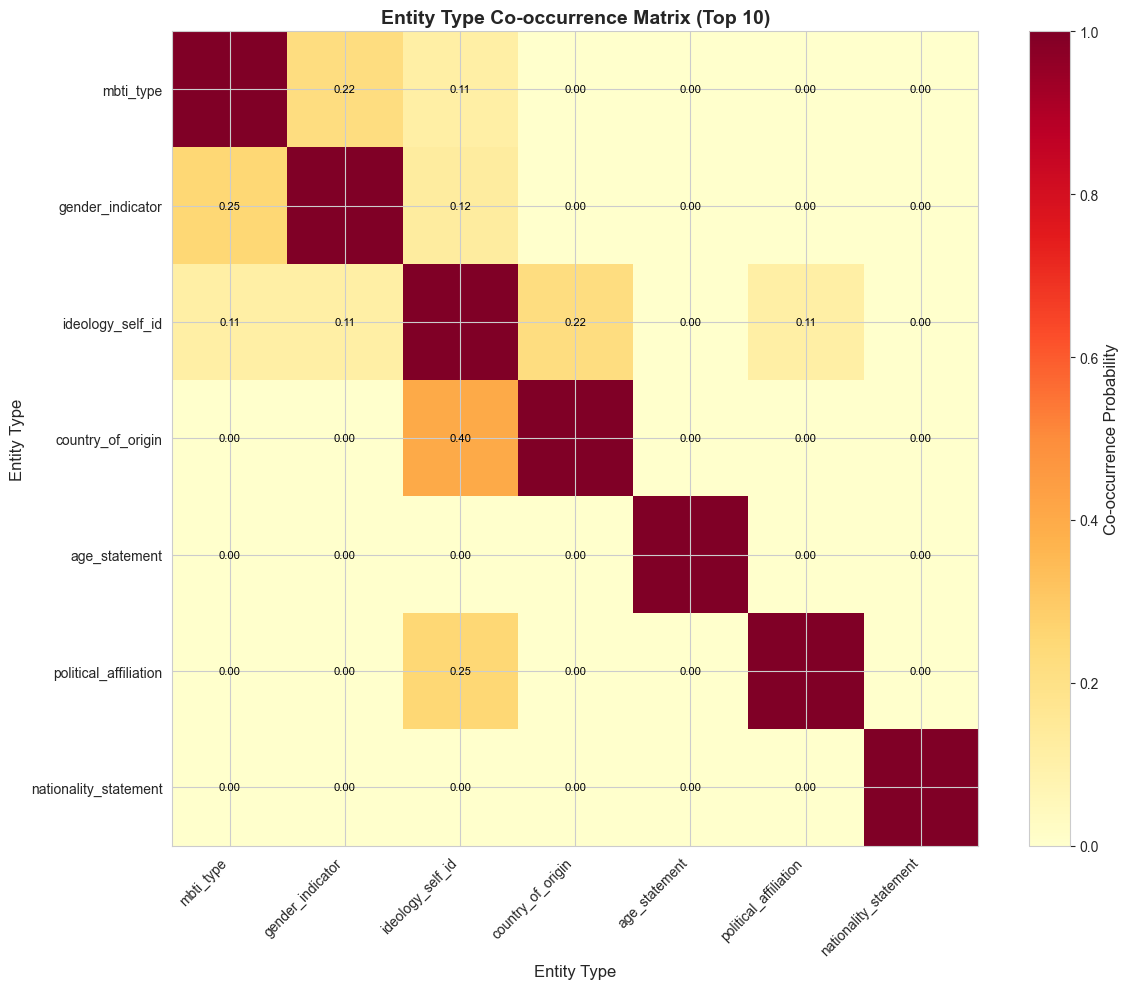

CO-OCCURRENCE INTERPRETATION
Each cell [i,j] shows: P(entity_j appears | entity_i appears)
High values indicate entity types that frequently appear together.


In [ ]:
# Column co-occurrence analysis
print("=" * 80)
print("COLUMN CO-OCCURRENCE IN POSTS")
print("=" * 80)

# Build column co-occurrence matrix
post_to_cols_detected = defaultdict(set)
for i in range(len(pollution_logs)):
    post_id = pollution_logs["post_id"][i].as_py()
    col = pollution_logs["entity_type"][i].as_py()
    post_to_cols_detected[post_id].add(col)

# Only consider posts with detections
cols_in_data = sorted(column_counts.keys())
cooccur_matrix = np.zeros((len(cols_in_data), len(cols_in_data)))

for post_cols in post_to_cols_detected.values():
    for i, col_i in enumerate(cols_in_data):
        for j, col_j in enumerate(cols_in_data):
            if col_i in post_cols and col_j in post_cols:
                cooccur_matrix[i, j] += 1

# Normalize by row (conditional probability)
row_sums = cooccur_matrix.sum(axis=1, keepdims=True)
cooccur_norm = np.divide(cooccur_matrix, row_sums, where=row_sums!=0)

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cooccur_norm, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('P(column_j detected | column_i detected)', fontsize=11)

ax.set_xticks(np.arange(len(cols_in_data)))
ax.set_yticks(np.arange(len(cols_in_data)))
ax.set_xticklabels(cols_in_data, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(cols_in_data, fontsize=9)

# Annotate cells
for i in range(len(cols_in_data)):
    for j in range(len(cols_in_data)):
        if i != j and cooccur_norm[i, j] > 0.05:
            text_color = "white" if cooccur_norm[i, j] > 0.5 else "black"
            ax.text(j, i, f'{cooccur_norm[i, j]:.2f}', ha="center", va="center", 
                   color=text_color, fontsize=7)

ax.set_title('Column Detection Co-occurrence Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("High co-occurrence means columns are often detected together in the same posts.")
print("=" * 80)

## 7. Masking Coverage Analysis

Analyze what percentage of text gets masked and masking density patterns.

MASKING COVERAGE STATISTICS
Total posts analyzed: 100
Posts with entities:  35 (35.0%)

Mask coverage statistics (for posts with entities):
count    35.000000
mean      0.002561
std       0.002769
min       0.000232
50%       0.001639
90%       0.005863
95%       0.007900
99%       0.011244
max       0.012469


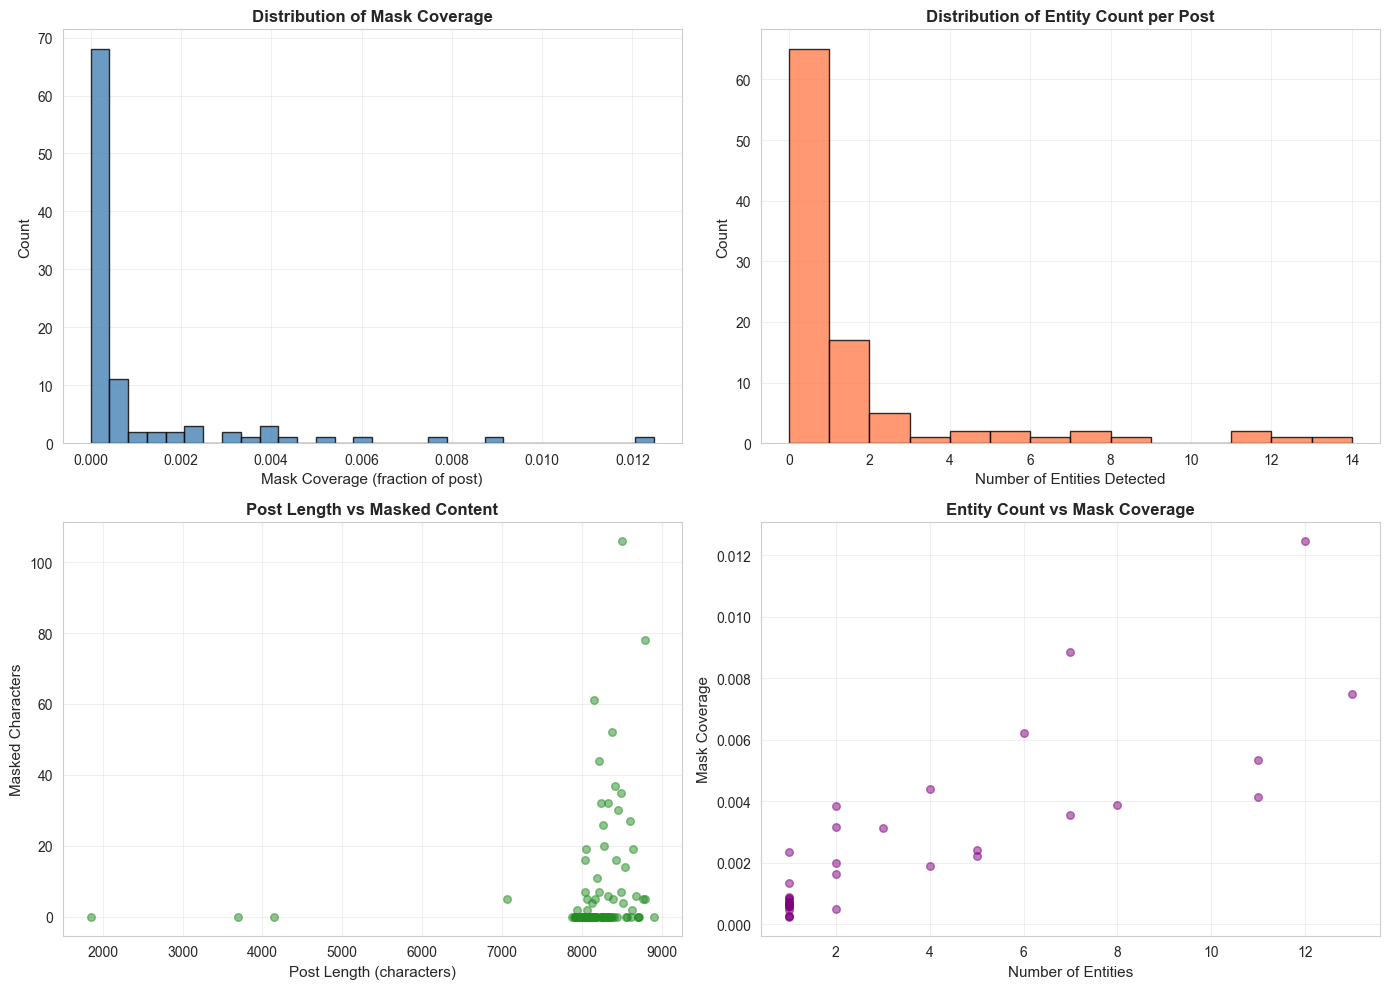


TOP 3 POSTS BY MASK COVERAGE

Post 99: 1.2% masked (12 entities)
Original length: 8501 chars
Sample: always done by random mutations, and those mutations aren't always good. If the "no-tusk" mutation is helpful enough, it'll spread and elephants as a whole will have evolved. If the drawbacks are wors...

Post 3: 0.9% masked (7 entities)
Original length: 8798 chars
Sample: terrain were too diverse, and leftover institutions were too ineffective. I don't, they usually make some great points. Have been it? Most of Latin America at the time had already outlawed Slavery. Th...

Post 67: 0.7% masked (13 entities)
Original length: 8149 chars
Sample: that I'm carrying a very heavy responsiblity. &gt;Remember, life’s about the simple things and you have to take baby steps There is so much I need to learn from you friends.. Thanks..! HOW!? You can't...


In [ ]:
# Masking coverage analysis by column
print("=" * 80)
print("MASKING COVERAGE ANALYSIS")
print("=" * 80)

# Compute coverage statistics per post
mask_stats = []
for i in range(len(table_with_masked)):
    post = posts[i]
    post_masked = post_masked_list[i]
    post_len = len(post)
    
    # Count masked characters
    masked_chars = sum(len(token) for token in post_masked.split() if token.startswith('[MASK:'))
    n_entities = len(entities_batch[i])
    mask_coverage = masked_chars / post_len if post_len > 0 else 0.0
    
    mask_stats.append({
        'post_id': post_ids[i],
        'post_length': post_len,
        'n_entities': n_entities,
        'mask_coverage': mask_coverage,
        'has_mask': '[MASK:' in post_masked,
    })

mask_df = pd.DataFrame(mask_stats)

print(f"Posts with masking: {mask_df['has_mask'].sum():,} / {len(mask_df):,} ({100*mask_df['has_mask'].sum()/len(mask_df):.1f}%)")
print(f"\nMask coverage statistics (for masked posts):")
masked_posts = mask_df[mask_df['has_mask']]
if len(masked_posts) > 0:
    print(masked_posts['mask_coverage'].describe(percentiles=[0.5, 0.75, 0.9, 0.95]).to_string())

# Plot masking distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Entity count distribution
axes[0, 0].hist(mask_df['n_entities'], bins=range(0, min(50, mask_df['n_entities'].max()+2)), 
                alpha=0.8, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Entities Detected per Post', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Distribution of Entity Count per Post', fontsize=12, fontweight='bold')
axes[0, 0].set_yscale('log')
axes[0, 0].grid(alpha=0.3)

# Plot 2: Mask coverage for masked posts
if len(masked_posts) > 0:
    axes[0, 1].hist(masked_posts['mask_coverage'], bins=40, alpha=0.8, 
                    color='coral', edgecolor='black')
    axes[0, 1].axvline(masked_posts['mask_coverage'].median(), color='red', 
                       linestyle='--', linewidth=2, label=f"Median={masked_posts['mask_coverage'].median():.2%}")
    axes[0, 1].set_xlabel('Mask Coverage', fontsize=11)
    axes[0, 1].set_ylabel('Frequency', fontsize=11)
    axes[0, 1].set_title('Mask Coverage Distribution (Masked Posts Only)', fontsize=12, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

# Plot 3: Entity count by column
col_entity_counts = column_counts
cols_plot = sorted(col_entity_counts.keys(), key=lambda x: col_entity_counts[x], reverse=True)[:8]
counts_plot = [col_entity_counts[c] for c in cols_plot]
axes[1, 0].bar(range(len(cols_plot)), counts_plot, color='forestgreen', alpha=0.8)
axes[1, 0].set_xticks(range(len(cols_plot)))
axes[1, 0].set_xticklabels(cols_plot, rotation=45, ha='right', fontsize=9)
axes[1, 0].set_ylabel('Detection Count', fontsize=11)
axes[1, 0].set_title('Top 8 Columns by Detection Count', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='y')

# Plot 4: Post length vs entity count
sample_for_scatter = mask_df.sample(min(5000, len(mask_df)), random_state=42)
axes[1, 1].scatter(sample_for_scatter['post_length'], sample_for_scatter['n_entities'], 
                   alpha=0.3, s=10, color='purple')
axes[1, 1].set_xlabel('Post Length (characters)', fontsize=11)
axes[1, 1].set_ylabel('Entity Count', fontsize=11)
axes[1, 1].set_title('Post Length vs Entity Detection Count', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("=" * 80)